In [1]:
import sys; print(sys.executable)

/home/User/miniconda3/envs/rugby/bin/python


In [3]:
import numpy as np, matplotlib.pyplot as plt, sys
from pathlib import Path
sys.path.append(str(Path.home()/ "rugby-video-analytics"))
from phase2.temporal import smooth_sheet, observed_mask, estimate_sigma_m

D = Path.home() / "data/phase2_npz"
STEM = "P9201256"; FUSION_WIN = (3282, 3356)
BODY12 = list(range(5,17))
def load(person, fusion):
    z = np.load(D / f"yolo_raw_{STEM}_{person}_{fusion}.npz")
    return dict(coords=z["coords"], confs=z["confs"], bbox=z["bbox"], frames=z["frame_index"], n_det=z["n_det"])
S={(p,f): load(p,f) for p in ("tackler", "carrier") for f in ("assign", "drop")}
print({k: v["coords"].shape for k, v in S.items()})

{('tackler', 'assign'): (195, 17, 2), ('tackler', 'drop'): (195, 17, 2), ('carrier', 'assign'): (195, 17, 2), ('carrier', 'drop'): (195, 17, 2)}


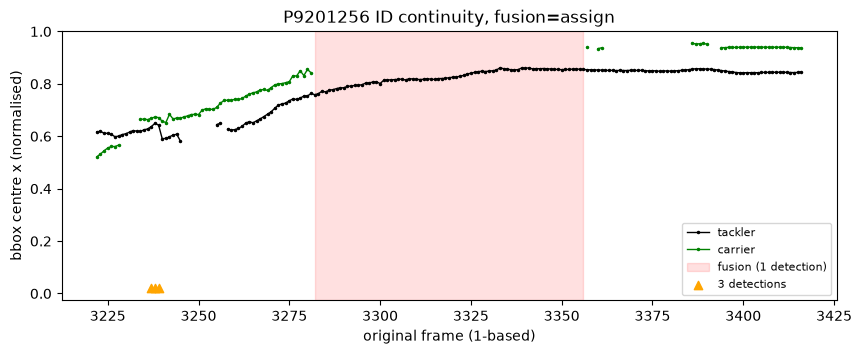

In [4]:
fr = S[("tackler", "assign")]["frames"]; nd = S[("tackler", "assign")]["n_det"]
fig, ax = plt.subplots(figsize=(10, 3.5))
for p, c in (("tackler", "k"), ("carrier", "g")):
    cx = S[(p, "assign")]["bbox"][:, 0].copy(); cx[cx == 0] = np.nan     # missing -> gap in the line
    ax.plot(fr, cx, c, marker=".", ms=3, lw=1, label=p)
ax.axvspan(*FUSION_WIN, color="r", alpha=0.12, label="fusion (1 detection)")
three_detection_mask = nd == 3
ax.scatter(fr[three_detection_mask], np.full(three_detection_mask.sum(), 0.02),
           marker="^", c="orange", label="3 detections")
ax.set(xlabel="original frame (1-based)", ylabel="bbox centre x (normalised)", title=f"{STEM} ID continuity, fusion=assign")
ax.legend(fontsize=8); plt.show()

In [6]:
SIGMA_A = 3e-4  # provisional (worksheet exercise c); select later by hide-and-predict
out = {}
for key, s in S.items():
    c12, k12 = s["coords"][:, BODY12], s["confs"][:, BODY12]
    obs = observed_mask(c12, k12)
    sm = estimate_sigma_m(c12, obs)
    out[key] = dict(obs=obs, sigma_m=sm, **smooth_sheet(c12, k12, SIGMA_A, sm))
    print(key, f"sigma_m = {sm:.5f}", " observed joint-frames:", int(obs.sum()), "/", obs.size)

('tackler', 'assign') sigma_m = 0.00682  observed joint-frames: 1939 / 2340
('tackler', 'drop') sigma_m = 0.01034  observed joint-frames: 892 / 2340
('carrier', 'assign') sigma_m = 0.00990  observed joint-frames: 682 / 2340
('carrier', 'drop') sigma_m = 0.00848  observed joint-frames: 557 / 2340


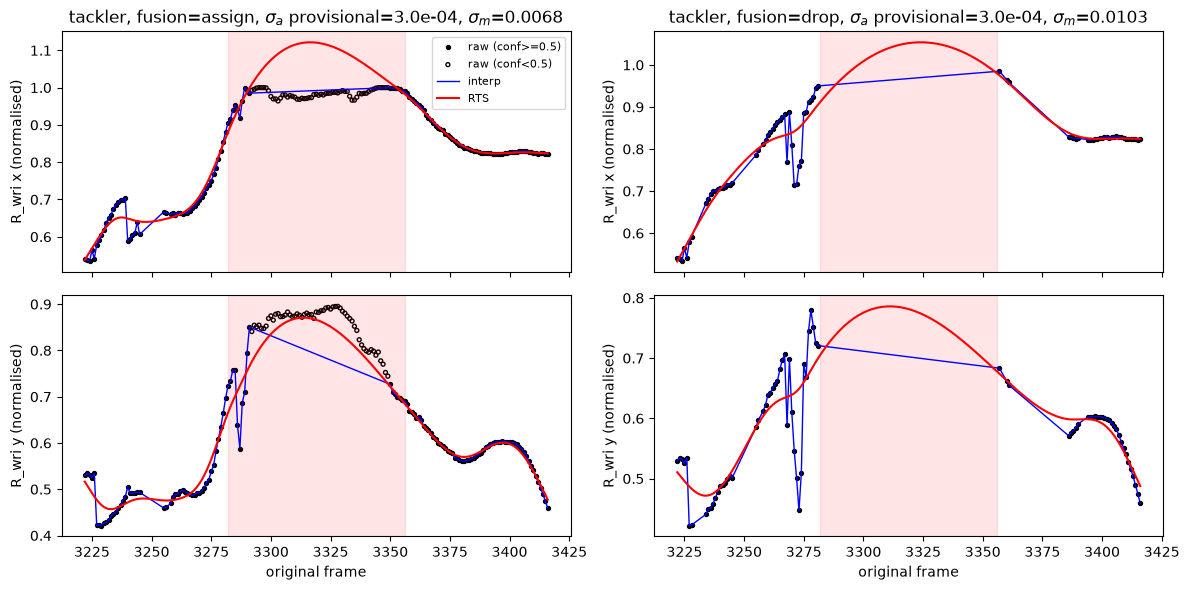

In [8]:
J = 5
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for col, fus in enumerate(("assign", "drop")):
    s, o = S[("tackler", fus)], out[("tackler", fus)]
    fr = s["frames"]
    z = s["coords"][:, BODY12[J]]
    ob = o["obs"][:, J]
    has = z[:, 0] != 0
    for row, name in enumerate("xy"):
        ax = axes[row, col]
        ax.scatter(fr[ob], z[ob, row], s=8, c="k", label="raw (conf>=0.5)")
        ax.scatter(fr[has & ~ob], z[has & ~ob, row], s=8, facecolors="none", edgecolors="k", label="raw (conf<0.5)")
        ax.plot(fr, o["interp"][:, J, row], "b-", lw=1, label="interp")
        ax.plot(fr, o["smooth"][:, J, row], "r-", lw=1.5, label="RTS")
        ax.axvspan(*FUSION_WIN, color="r", alpha=0.10)
        ax.set_ylabel(f"R_wri {name} (normalised)")
        if row == 0:
            ax.set_title(rf"tackler, fusion={fus}, $\sigma_a$ provisional={SIGMA_A:.1e}, $\sigma_m$={o['sigma_m']:.4f}")
axes[1, 0].set_xlabel("original frame")
axes[1, 1].set_xlabel("original frame")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
figure_path = Path.home() / "rugby-video-analytics" / "phase2" / "results" / "fig_temporal_P9201256_tackler_Rwri.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, dpi=120)
plt.show()